# Analiza comportamentului unui agent DRL ierarhic în supply chain implementat cu algoritmul A2C


---

## Structură
- **H1** — Cererea nu urmează o distribuție normală (Shapiro-Wilk + EDA)
- **H2** — Efectul Bullwhip: agentul amplifică volatilitatea în ierarhie (CV)
- **H3** — Asimetria pozitivă sistematică a comenzilor agentului (Skewness + test t)
- **H4** — Sensitivity Analysis: robustețea agentului la modificări de lead time

**Date utilizate:** `incoming_orders.csv`(fișier din proiect utilizat ca model pt structura cererii), `dc_order_list.csv`(fișier generat de simulator), `sensitivity_results.csv` (fișier generat de simulator de clasa scrisă de mine )
 Funcția `generate_orders()` a fost apelată de 3.000 de ori pentru a aproxima distribuția reală a cererii stochastice, reducând influența variațiilor accidentale și asigurând stabilitatea testelor statistice.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, csv, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import shapiro, ttest_1samp, pearsonr
from scipy import stats as sp

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi']        = 120

DATA       = '/content/drive/MyDrive/licenta_drl/data'
ORDER_PATH = os.path.join(DATA, 'incoming_orders.csv')
DC_PATH    = os.path.join(DATA, 'dc_order_list.csv')

print('Fișiere găsite:', os.path.exists(ORDER_PATH), os.path.exists(DC_PATH))

Mounted at /content/drive
Fișiere găsite: True True


### Generare date pentru H1-H3

Funcția `generate_orders()` reproduce exact logica din `file_operations.py` al proiectului.  
La fiecare apel introduce trei tipuri de comportament stochastic:
- **~10%** comenzi omise complet (cerere = 0)
- **~10%** cantitate dublată (spike de cerere)
- **~80%** perturbare uniformă cu factor ciclic f ∈ {0.2, 0.4, 0.6, 0.8}

Deși `incoming_orders.csv` conține 3 înregistrări cu part numbers diferite, simulatorul folosește la antrenament un singur produs (Brake Pads, `0A23123674C`, cantitate de bază 400). Celelalte două înregistrări sunt template-uri din fișierul original. Am ales să le analizez pe  toate trei pentru a caracteriza complet mecanismul de generare.

In [ ]:
def generate_orders(filepath):

    new_orders = []
    with open(filepath) as f:
        reader = csv.reader(f)
        new_orders.append(next(reader))
        counter = 1
        for row in reader:
            if random.random() < .1:
                pass
            elif random.random() > .9:
                row[4] = round(int(row[4]) * 2, 0)
                row[0] = counter; counter += 1
                new_orders.append(row)
            else:
                mf = ((int(row[0]) % 4) + 1) * .2
                lb = int(round(int(row[4]) * (1 - mf), 0))
                hb = int(round(int(row[4]) * (1 + mf), 0))
                if lb >= hb: hb = lb + 1
                row[4] = random.randrange(lb, hb)
                row[0] = counter; counter += 1
                new_orders.append(row)
    return new_orders

# Simulare 3000 apeluri per înregistrare
parts  = ['0A23123674C', '1H0615601G3', '3JK43234321']
base   = {'0A23123674C': 400, '1H0615601G3': 250, '3JK43234321': 1100}
pname  = {'0A23123674C': 'Produs A (baza 400)',
          '1H0615601G3': 'Produs B (baza 250)',
          '3JK43234321': 'Produs C (baza 1100)'}
demand = {p: [] for p in parts}

for _ in range(3000):
    orders = generate_orders(ORDER_PATH)
    seen = set()
    for row in orders[1:]:
        p = row[3]
        if p in demand:
            demand[p].append(int(row[4]))
            seen.add(p)
    for p in parts:
        if p not in seen:
            demand[p].append(0)

demand_arr = {p: np.array(v) for p, v in demand.items()}

# Citire dc_order_list.csv (comenzi agregate generate de agenții antrenați)
dc_rows = []
with open(DC_PATH, newline='', encoding='utf-8') as f:
    for row in csv.reader(f):
        if not row: continue
        clean = [float(x) for x in (row[0].split(',') if len(row)==1 else row) if x.strip()]
        dc_rows.append(clean)

dc_all    = np.array([v for r in dc_rows for v in r])
local_agg = np.array([sum(demand_arr[p][i] for p in parts) for i in range(3000)])

print(f'generate_orders: 3.000 simulări ')
print(f'dc_order_list:   {len(dc_rows)} secvențe × {len(dc_rows[0])} valori = {len(dc_all):,} total')

generate_orders: 3.000 simulări 
dc_order_list:   1000 secvențe × 1015 valori = 1,015,000 total


---
## H1 — Cererea nu urmează o distribuție normală

**Context teoretic:** Modelul EOQ (Economic Order Quantity) presupune că cererea D este constantă sau normală, permițând calculul analitic: Q* = √(2DS/H). Dacă distribuția reală diferă semnificativ, formula produce rezultate suboptimale — fie stockout, fie costuri de holding ridicate.

**Metodă:** Test Shapiro-Wilk  pe eșantion de 500 din cele 3.000 observații simulate, plus statistici descriptive (CV, zerouri%, spike%).

In [ ]:
np.random.seed(42)
print(f'{"Produs":<22} {"Media":>7} {"Std":>7} {"CV%":>6} {"Zero%":>7} {"Spike%":>7} {"W":>7} {"p-value":>10}')
print('-' * 76)
for p in parts:
    arr  = demand_arr[p]
    W, pv = shapiro(np.random.choice(arr, 500, replace=False))
    print(f'{pname[p]:<22} {arr.mean():>7.1f} {arr.std():>7.1f} '
          f'{arr.std()/arr.mean()*100:>6.1f} '
          f'{(arr==0).mean()*100:>7.1f} '
          f'{(arr>=base[p]*1.8).mean()*100:>7.1f} '
          f'{W:>7.4f} {pv:>10.2e}')
print()

Produs                   Media     Std    CV%   Zero%  Spike%       W    p-value
----------------------------------------------------------------------------
Produs A (baza 400)      390.9   195.9   50.1    11.0     8.8  0.9125   2.17e-16
Produs B (baza 250)      245.1   131.2   53.6     9.8     8.1  0.9662   2.54e-09
Produs C (baza 1100)    1100.7   675.3   61.3    10.6     9.4  0.9612   3.33e-10



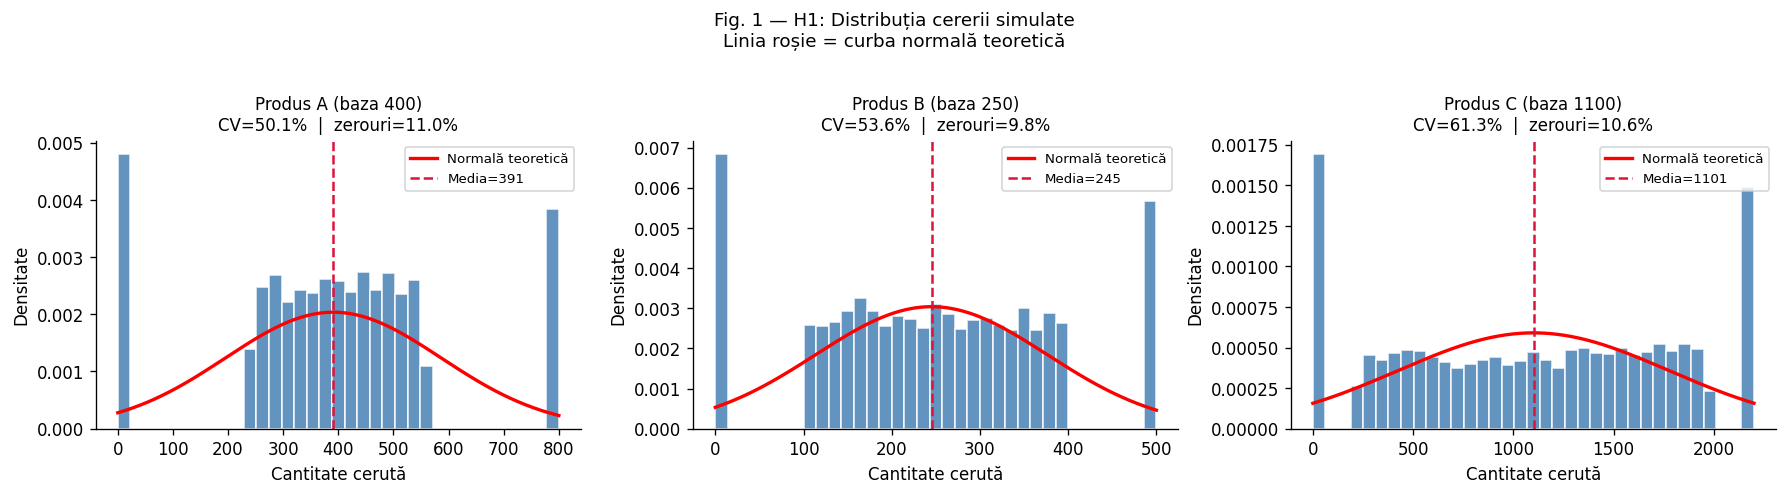

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, p in enumerate(parts):
    arr = demand_arr[p]
    ax  = axes[col]
    ax.hist(arr, bins=35, color='steelblue', edgecolor='white', alpha=0.85, density=True)
    x = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(x, sp.norm.pdf(x, arr.mean(), arr.std()), 'r-', lw=2, label='Normală teoretică')
    ax.axvline(arr.mean(), color='crimson', ls='--', lw=1.5, label=f'Media={arr.mean():.0f}')
    ax.set_title(f'{pname[p]}\nCV={arr.std()/arr.mean()*100:.1f}%  |  zerouri={( arr==0).mean()*100:.1f}%', fontsize=10)
    ax.set_xlabel('Cantitate cerută')
    ax.set_ylabel('Densitate')
    ax.legend(fontsize=8)
plt.suptitle('Fig. 1 — H1: Distribuția cererii simulate\nLinia roșie = curba normală teoretică', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

**Interpretare H1:**

Testul Shapiro-Wilk respinge normalitatea pentru toate cele 3 înregistrări (p << 0.05, W sub 1.0). Histogramele confirmă structura trimodală: vârf la zero (aprox 10% zile fără comandă), masă principală de valori variabile și vârf la valoarea dublată (aprox 10% spike-uri). Curba normală teoretică (linia roșie) nu se potrivește cu niciuna dintre aceste zone.

Coeficienții de variație între 50% și 61% reflectă variabilitate ridicată incompatibilă cu ipoteza EOQ de cerere aproximativ constantă.

**Concluzie:** Cererea simulată nu poate fi tratată ca normală, invalidând aplicabilitatea modelelor clasice. Aceasta furnizează justificarea pentru utilizarea unui agent DRL care nu presupune nicio formă a distribuției cererii, ci o învață direct prin experiență.

---
## H2 — Efectul Bullwhip: agentul amplifică volatilitatea în ierarhie

**Context teoretic:** Efectul Bullwhip  descrie amplificarea variabilității comenzilor pe măsura urcării în ierarhia unui lanț de aprovizionare. Cauzele clasice: actualizarea previziunilor, politici de comandă în loturi, fluctuații de prețuri. Rozhkov & Alyamovskaya (2025) demonstrează că sistemele multi-echelon DRL pot genera Bullwhip din optimizarea descentralizată.

**Metodă:** Coeficientul de Variație CV = σ/μ × 100% — măsură care permite compararea variabilității la scale diferite. Dacă CV_regional > CV_local → efect Bullwhip prezent.

**Date:** `dc_order_list.csv` conține 1.000 serii × 1.015 valori = comenzile agregate generate de cei 4 agenți A2C de nivel 1 (Charlotte, Nashville, Chicago, Toronto) — outputul direct al rețelelor neuronale.

In [ ]:
np.random.seed(42)
cv_local    = local_agg.std() / local_agg.mean() * 100
cv_regional = dc_all.std()    / dc_all.mean()    * 100
raport      = cv_regional / cv_local
seq_cvs     = [np.std(r)/np.mean(r)*100 for r in dc_rows if np.mean(r) > 0]

print('COMPARATIE CV — BULLWHIP EFFECT')
print(f'{"":30} {"Local":>10} {"Regional":>10}')
print('-' * 52)
print(f'{"Media (unitati)":30} {local_agg.mean():>10.1f} {dc_all.mean():>10.1f}')
print(f'{"Std (unitati)":30} {local_agg.std():>10.1f} {dc_all.std():>10.1f}')
print(f'{"CV (%)":30} {cv_local:>10.1f} {cv_regional:>10.1f}')
print('-' * 52)
print(f'Raport amplificare: {raport:.2f}x')
print(f'Secvente cu CV > CV_local: {sum(c > cv_local for c in seq_cvs)}/1000 ')

COMPARATIE CV — BULLWHIP EFFECT
                                    Local   Regional
----------------------------------------------------
Media (unitati)                    1736.7     1977.2
Std (unitati)                       709.9     1281.9
CV (%)                               40.9       64.8
----------------------------------------------------
Raport amplificare: 1.59x
Secvente cu CV > CV_local: 1000/1000 


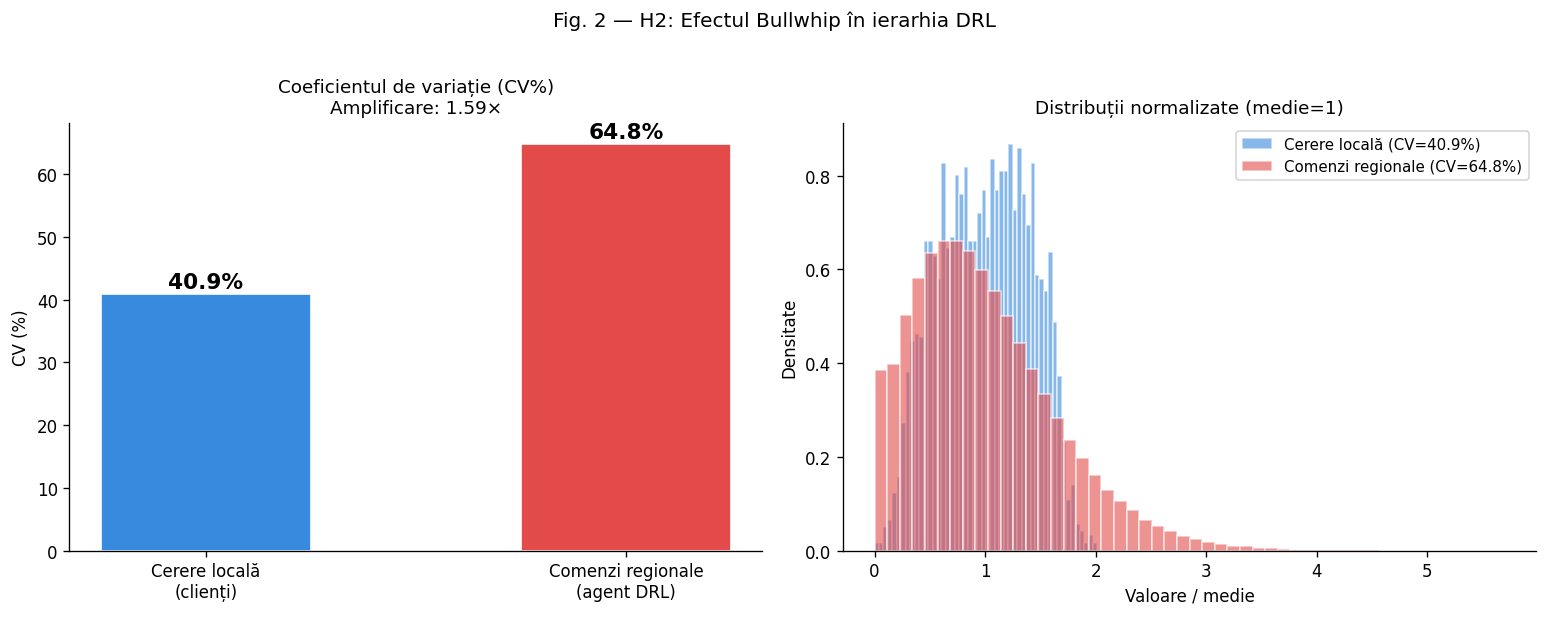

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot CV
bars = axes[0].bar(['Cerere locală\n(clienți)', 'Comenzi regionale\n(agent DRL)'],
                   [cv_local, cv_regional], color=['#378ADD','#E24B4A'],
                   edgecolor='white', width=0.5)
for b, v in zip(bars, [cv_local, cv_regional]):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title(f'Coeficientul de variație (CV%)\nAmplificare: {raport:.2f}×', fontsize=11)
axes[0].set_ylabel('CV (%)')

# Histograme
loc_norm = local_agg / local_agg.mean()
reg_norm = dc_all    / dc_all.mean()
axes[1].hist(loc_norm, bins=50, alpha=0.6, color='#378ADD', density=True,
             edgecolor='white', label=f'Cerere locală (CV={cv_local:.1f}%)')
axes[1].hist(reg_norm, bins=50, alpha=0.6, color='#E24B4A', density=True,
             edgecolor='white', label=f'Comenzi regionale (CV={cv_regional:.1f}%)')
axes[1].set_title('Distribuții normalizate (medie=1)', fontsize=11)
axes[1].set_xlabel('Valoare / medie')
axes[1].set_ylabel('Densitate')
axes[1].legend(fontsize=9)

plt.suptitle('Fig. 2 — H2: Efectul Bullwhip în ierarhia DRL', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**Interpretare H2:**

CV-ul comenzilor regionale (64.8%) este cu **1.59× mai mare** decât CV-ul cererii locale agregate (40.9%). Proprietatea este sistematică: toate cele 1.000 de secvențe din `dc_order_list.csv` au CV mai mare decât cererea locală — fără nicio excepție.

**Concluzie:** Arhitectura DRL ierarhică descentralizată induce un efect Bullwhip cuantificabil. Optimizarea locală corectă a fiecărui agent de nivel 1 produce colectiv instabilitate la nivelul 2 — un compromis arhitectural identificabil statistic, nu o eroare de antrenament. Rezultatul este consistent cu Rozhkov & Alyamovskaya (2025).

---
## H3 — Asimetria pozitivă sistematică a comenzilor agentului

**Context teoretic:** Un agent rațional cu funcție de recompensă asimetrică va dezvolta o politică asimetrică. În proiect, `calculate_reward()` din `dist_center.py` returnează **-1** pentru stoc sub `min_stop_val=0.2` (stockout), dar permite suprastocare până la `max_stop_val=1.5` cu penalizări mici (-0.5 pentru comanda navală redundantă). Această asimetrie creează un stimul implicit de supra-comandă precaută.

**Metodă:** Skewness = E[(X-μ)³]/σ³ și test t unilatral (H0: skew_mediu = 0) pe 1.000 de secvențe.

In [ ]:
np.random.seed(42)
# Skewness per secvență (comenzi regionale)
skews    = [float(np.mean((np.array(r)-np.mean(r))**3)/np.std(r)**3)
            for r in dc_rows if np.std(r) > 0]
sk       = np.array(skews)
t_stat, p_val = ttest_1samp(sk, popmean=0)

# Skewness cerere locală
sk_local = [float(np.mean((demand_arr[p]-demand_arr[p].mean())**3)/demand_arr[p].std()**3)
            for p in parts]

print('ANALIZA SKEWNESS')
print('Cerere locală :')
for p, s in zip(parts, sk_local):
    print(f'  {pname[p]}: skewness = {s:+.4f}')
print()
print('Comenzi regionale (dc_order_list.csv — 1.000 secvențe):')
print(f'  Skewness mediu:        {sk.mean():+.4f}')
print(f'  Std skewness:          {sk.std():.4f}')
print(f'  % secvențe skew > 0:   {(sk > 0).mean()*100:.1f}%')
print(f'  % secvențe skew > 0.5: {(sk > 0.5).mean()*100:.1f}%')
print()
print(f'Test t (H0: skew=0): t={t_stat:.2f}, p={p_val:.2e}')


ANALIZA SKEWNESS
Cerere locală :
  Produs A (baza 400): skewness = -0.0488
  Produs B (baza 250): skewness = -0.0020
  Produs C (baza 1100): skewness = -0.0419

Comenzi regionale (dc_order_list.csv — 1.000 secvențe):
  Skewness mediu:        +0.9150
  Std skewness:          0.1045
  % secvențe skew > 0:   100.0%
  % secvențe skew > 0.5: 100.0%

Test t (H0: skew=0): t=276.84, p=0.00e+00


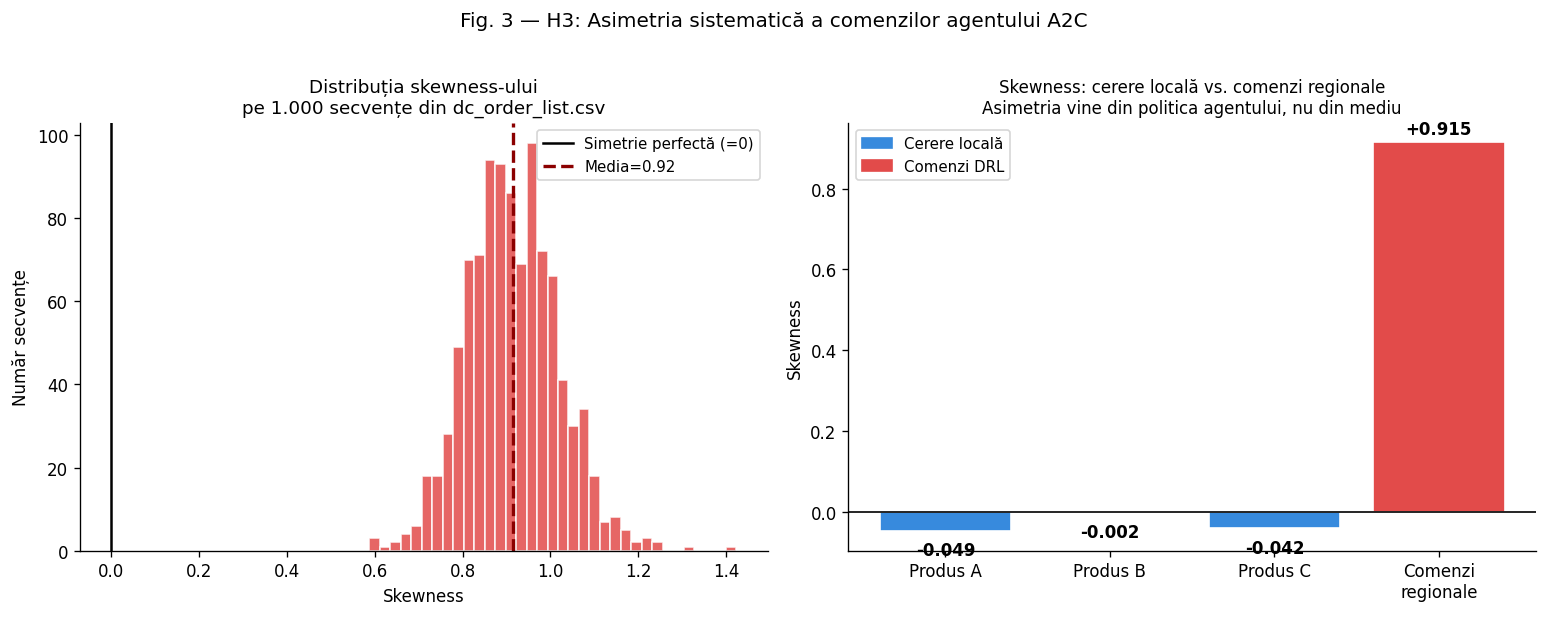

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribuția skewness pe 1000 secvențe
axes[0].hist(sk, bins=35, color='#E24B4A', edgecolor='white', alpha=0.85)
axes[0].axvline(0,         color='black',   lw=1.5, label='Simetrie perfectă (=0)')
axes[0].axvline(sk.mean(), color='darkred', lw=2.0, ls='--', label=f'Media={sk.mean():.2f}')
axes[0].set_title('Distribuția skewness-ului\npe 1.000 secvențe din dc_order_list.csv', fontsize=11)
axes[0].set_xlabel('Skewness')
axes[0].set_ylabel('Număr secvențe')
axes[0].legend(fontsize=9)

# Comparație skewness local vs. regional
vals   = sk_local + [sk.mean()]
labels = ['Produs A', 'Produs B', 'Produs C', 'Comenzi\nregionale']
colors = ['#378ADD','#378ADD','#378ADD','#E24B4A']
bars   = axes[1].bar(labels, vals, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', lw=1)
for b, v in zip(bars, vals):
    axes[1].text(b.get_x()+b.get_width()/2, v+(0.02 if v>=0 else -0.06),
                 f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Skewness: cerere locală vs. comenzi regionale\nAsimetria vine din politica agentului, nu din mediu', fontsize=10)
axes[1].set_ylabel('Skewness')
axes[1].legend(handles=[mpatches.Patch(color='#378ADD', label='Cerere locală'),
                         mpatches.Patch(color='#E24B4A', label='Comenzi DRL')], fontsize=9)

plt.suptitle('Fig. 3 — H3: Asimetria sistematică a comenzilor agentului A2C', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Interpretare H3:**

Skewness-ul mediu al comenzilor regionale este **+0.9150**, semnificativ diferit de zero (t=276.84, p≈0). Toate cele 1.000 de secvențe au skewness pozitiv și mai mare de 0.5. Prin comparație, cererea locală are skewness aproape de zero (-0.049 la -0.002) ,deci asimetria **nu vine din mediu, ci din politica agentului**.

**Concluzie:** Agentul a internalizat asimetria funcției de recompensă și a dezvoltat o strategie de supra-comandă precaută ca proprietate emergentă a antrenamentului. Aceasta nu a fost programată explicit, ci a fost descoperită prin optimizare în interacțiunea cu funcția de recompensă asimetrică.

---
## H4 — Sensitivity Analysis: Robustețea agentului la modificări de lead time

**Context teoretic:** Agentii DRL sunt antrenatit în condiții specifice și pot manifesta sensibilitate la schimbări ale distribuției de input față de cea de antrenament-fenomen similar covariate shift din transfer learning. Lead time-urile sunt parametri centrali: agentul a internalizat valorile fixe plane=2, freight=7, ship=14 zile. Când acestea se schimbă în deployment fără reantrenare, apare o inconsistență între presupunerile agentului și realitatea mediului.

**Metodă:** Am creat clasa `PerturbedDistCenter` care suprascrie exclusiv `step()` din `DistCenter`, permițând lead times configurabile. Agentul antrenat rulează identic — doar mediul se schimbă. 12 scenarii în 5 categorii, 200 episoade fiecare, seed fix=42.  

Am făcut analiza la nivel local (DistCenter) pentru a izola efectul lead time-ului, evitând interferențele multi-agent specifice nivelului regional.

**Fișier folosit:** `sensitivity_results.csv` generat de `lead_time_sensitivity.py` (rulat local în proiect).

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('sensitivity_results.csv')

cat_order  = ['baseline', 'mild', 'severe', 'improved', 'stochastic']
cat_colors = {
    'baseline'  : '#2E75B6',
    'mild'      : '#ED7D31',
    'severe'    : '#C00000',
    'improved'  : '#375623',
    'stochastic': '#7030A0',
}
df['category'] = pd.Categorical(df['category'], categories=cat_order, ordered=True)
df = df.sort_values('category').reset_index(drop=True)
df['color'] = df['category'].map(cat_colors)

print(f'Scenarii încărcate: {len(df)}')
display(df[['scenario','category','plane_days','freight_days',
            'reward_mean','complete_pct','reward_per_step']].round(2))

Saving sensitivity_results.csv to sensitivity_results.csv
Scenarii încărcate: 12


,scenario,category,plane_days,freight_days,reward_mean,complete_pct,reward_per_step
0,Baseline,baseline,2,7,4801.40,70.5,5.58
1,Avion+1zi,mild,3,7,5647.89,70.0,6.59
2,Avion+2zile,mild,4,7,5604.14,69.0,6.60
3,Freight+3zile,mild,2,10,5319.16,68.5,6.28
4,Freight+5zile,mild,2,12,5278.06,69.0,6.29
5,Avion+Fr mild,severe,3,10,6080.10,66.5,7.30
6,Avion+Fr sever,severe,4,12,6074.42,66.0,7.30
7,Avion rapid,improved,1,7,6061.24,72.0,7.04
8,Freight rapid,improved,2,5,5568.66,70.5,6.49
9,Ambii rapizi,improved,1,5,6976.37,74.0,7.95


### Graficul 1 — Reward vs. Complete% per scenariu

Cele două metrici spun povești diferite și opuse:
- **Reward crește** la scenariile perturbate - comportament contraintuitiv logistic
- **Complete% scade** la aceleași scenarii - sistemul devine mai instabil

Această neconcordanță este concluzia centrală a analizei.

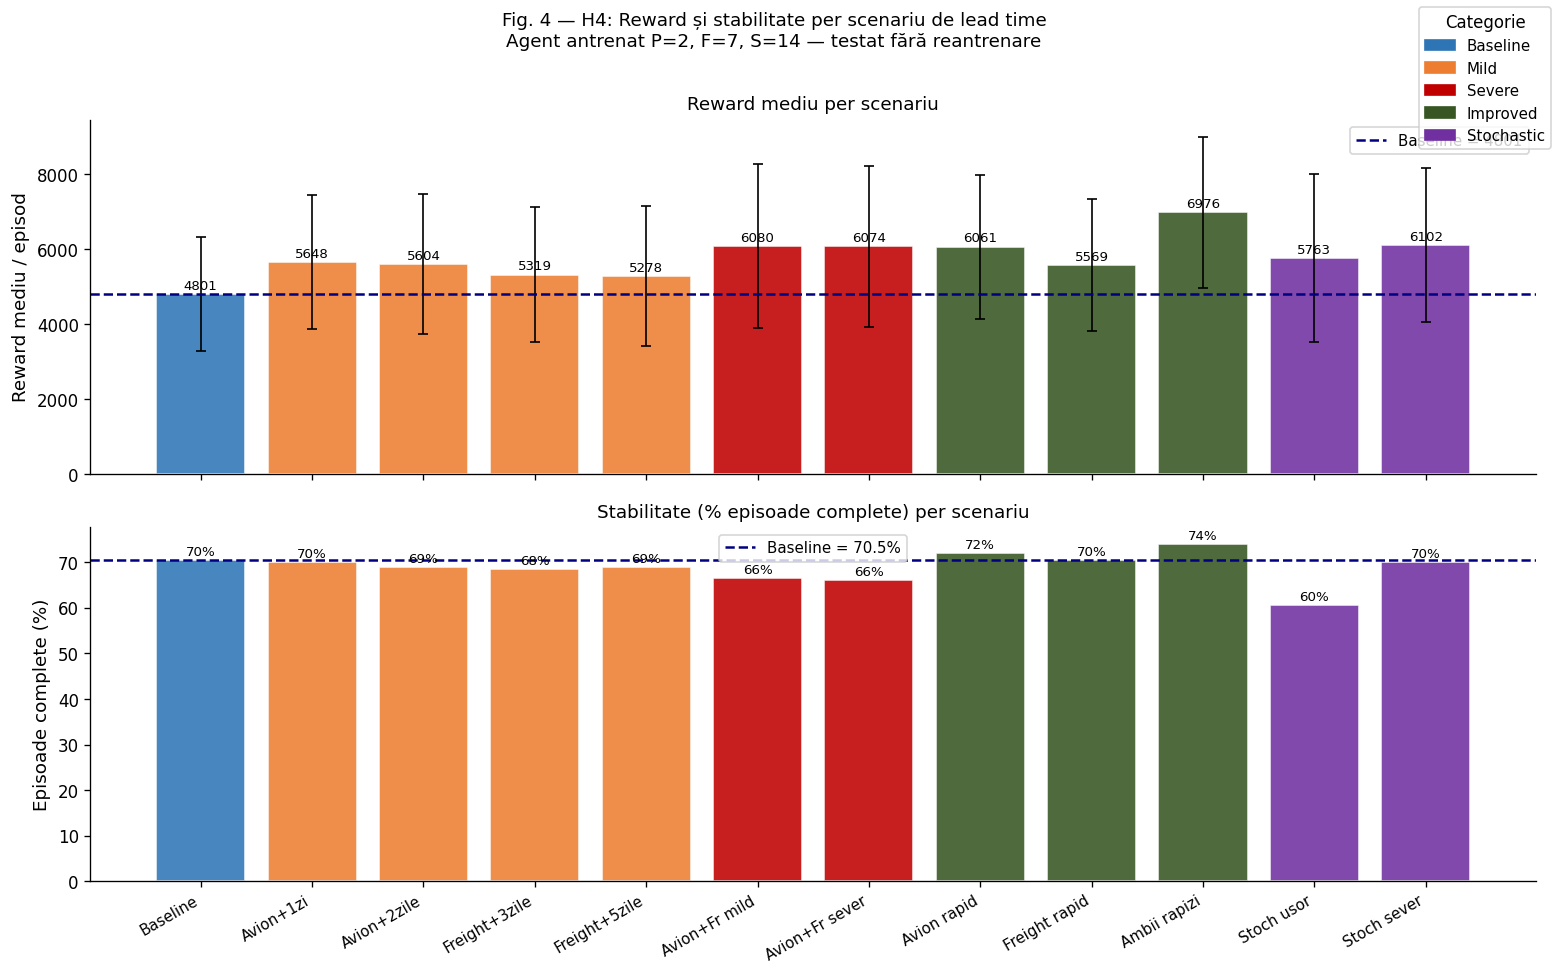

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
x      = np.arange(len(df))
colors = df['color'].tolist()

bars1 = ax1.bar(x, df['reward_mean'], color=colors, edgecolor='white', alpha=0.88)
ax1.errorbar(x, df['reward_mean'], yerr=df['reward_std'],
             fmt='none', color='black', capsize=3, linewidth=1)
baseline_r = df.loc[df['category']=='baseline', 'reward_mean'].values[0]
ax1.axhline(baseline_r, color='navy', ls='--', lw=1.5, label=f'Baseline = {baseline_r:.0f}')
for bar, v in zip(bars1, df['reward_mean']):
    ax1.text(bar.get_x()+bar.get_width()/2, v+50, f'{v:.0f}', ha='center', va='bottom', fontsize=8)
ax1.set_ylabel('Reward mediu / episod', fontsize=11)
ax1.set_title('Reward mediu per scenariu', fontsize=11)
ax1.legend(fontsize=9)

bars2 = ax2.bar(x, df['complete_pct'], color=colors, edgecolor='white', alpha=0.88)
baseline_c = df.loc[df['category']=='baseline', 'complete_pct'].values[0]
ax2.axhline(baseline_c, color='navy', ls='--', lw=1.5, label=f'Baseline = {baseline_c:.1f}%')
for bar, v in zip(bars2, df['complete_pct']):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.0f}%', ha='center', va='bottom', fontsize=8)
ax2.set_ylabel('Episoade complete (%)', fontsize=11)
ax2.set_title('Stabilitate (% episoade complete) per scenariu', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(df['scenario'], rotation=30, ha='right', fontsize=9)
ax2.legend(fontsize=9)

patches = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in cat_colors.items()]
fig.legend(handles=patches, loc='upper right', fontsize=9, title='Categorie')
plt.suptitle('Fig. 4 — H4: Reward și stabilitate per scenariu de lead time\nAgent antrenat P=2, F=7, S=14 — testat fără reantrenare',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### Graficul 2 — Medii pe categorii

Medii pe categorii:


,category,reward_mean,reward_std,complete_mean,complete_std
0,baseline,4801.40,NaN,70.50,NaN
1,mild,5462.31,190.61,69.12,0.63
2,severe,6077.26,4.02,66.25,0.35
3,improved,6202.09,714.35,72.17,1.76
4,stochastic,5932.59,239.54,65.25,6.72


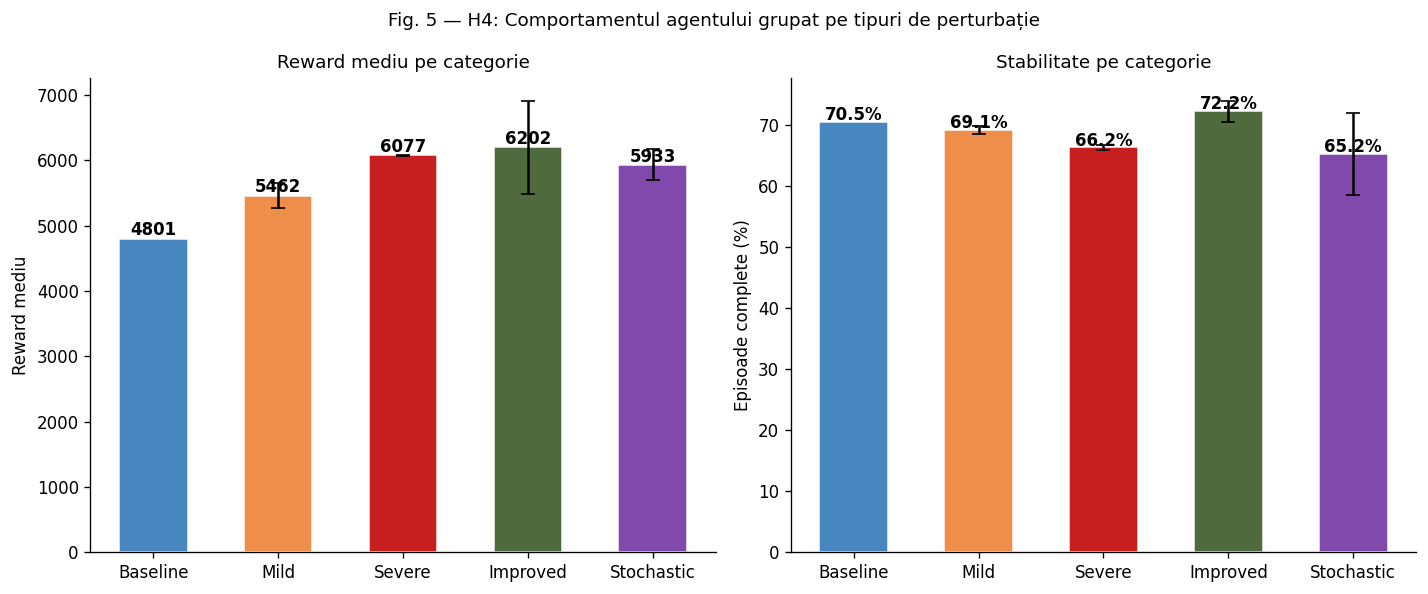

In [ ]:
grp = df.groupby('category', observed=True).agg(
    reward_mean   = ('reward_mean',  'mean'),
    reward_std    = ('reward_mean',  'std'),
    complete_mean = ('complete_pct', 'mean'),
    complete_std  = ('complete_pct', 'std'),
).reset_index()

print('Medii pe categorii:')
display(grp.round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
cats   = grp['category'].tolist()
colors_g = [cat_colors[c] for c in cats]
x      = np.arange(len(cats))

bars = ax1.bar(x, grp['reward_mean'], color=colors_g, edgecolor='white', alpha=0.88, width=0.55)
ax1.errorbar(x, grp['reward_mean'], yerr=grp['reward_std'], fmt='none', color='black', capsize=4)
for bar, v in zip(bars, grp['reward_mean']):
    ax1.text(bar.get_x()+bar.get_width()/2, v+50, f'{v:.0f}', ha='center', fontsize=10, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels([c.capitalize() for c in cats], fontsize=10)
ax1.set_ylabel('Reward mediu'); ax1.set_title('Reward mediu pe categorie', fontsize=11)

bars2 = ax2.bar(x, grp['complete_mean'], color=colors_g, edgecolor='white', alpha=0.88, width=0.55)
ax2.errorbar(x, grp['complete_mean'], yerr=grp['complete_std'], fmt='none', color='black', capsize=4)
for bar, v in zip(bars2, grp['complete_mean']):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels([c.capitalize() for c in cats], fontsize=10)
ax2.set_ylabel('Episoade complete (%)'); ax2.set_title('Stabilitate pe categorie', fontsize=11)

plt.suptitle('Fig. 5 — H4: Comportamentul agentului grupat pe tipuri de perturbație', fontsize=11)
plt.tight_layout()
plt.show()

### Graficul 3 — Corelația Reward vs. Complete%

O corelație slabă sau negativă demonstrează că reward-ul nu este un indicator bun al stabilității .

Corelație Pearson reward vs. complete%: r=0.192, p=0.5490
=> Corelație nesemnificativă: reward NU prezice stabilitatea.


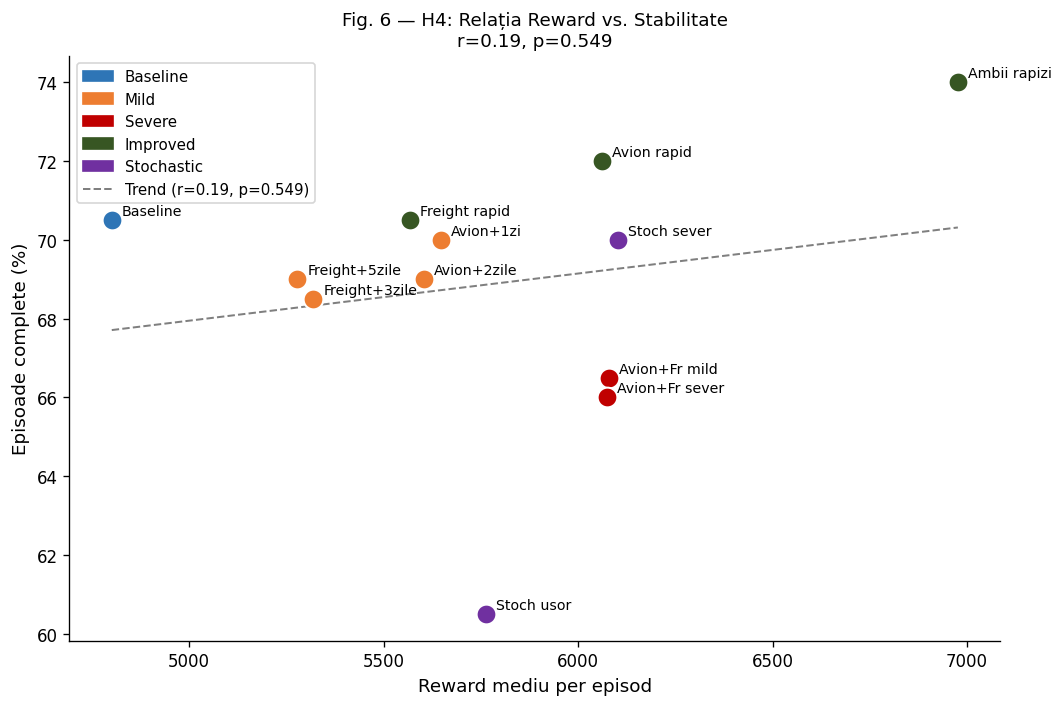

In [ ]:
r_corr, p_corr = pearsonr(df['reward_mean'], df['complete_pct'])
print(f'Corelație Pearson reward vs. complete%: r={r_corr:.3f}, p={p_corr:.4f}')
print('=> Corelație nesemnificativă: reward NU prezice stabilitatea.' if p_corr > 0.05
      else '=> Corelație semnificativă.')

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in df.iterrows():
    ax.scatter(row['reward_mean'], row['complete_pct'],
               s=140, color=cat_colors[row['category']], edgecolors='white', linewidth=1.2, zorder=3)
    ax.annotate(row['scenario'], (row['reward_mean'], row['complete_pct']),
                textcoords='offset points', xytext=(6, 3), fontsize=8.5)
z = np.polyfit(df['reward_mean'], df['complete_pct'], 1)
xline = np.linspace(df['reward_mean'].min(), df['reward_mean'].max(), 100)
ax.plot(xline, np.polyval(z, xline), 'k--', lw=1.2, alpha=0.5,
        label=f'Trend (r={r_corr:.2f}, p={p_corr:.3f})')
patches = [mpatches.Patch(color=v, label=k.capitalize()) for k, v in cat_colors.items()]
ax.legend(handles=patches+[ax.get_legend_handles_labels()[0][-1]], fontsize=9)
ax.set_xlabel('Reward mediu per episod', fontsize=11)
ax.set_ylabel('Episoade complete (%)', fontsize=11)
ax.set_title(f'Fig. 6 — H4: Relația Reward vs. Stabilitate\nr={r_corr:.2f}, p={p_corr:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

Interpretare H4:

1. **Necorelare Reward — Stabilitate:** Creșterea lead time-ului nu produce scăderea reward-ului. Reward-ul crește la scenariile perturbate (Severe: +26.6%) din cauza unei limitări structurale a funcției de recompensă: `calculate_reward()` penalizează suprapunerea comenzilor pe același slot temporal, nu întârzierea logistică în sine. Corelația Pearson r=0.192, p=0.549 confirmă că reward și complete% sunt nealiniate — **reward nu prezice stabilitatea**.

2. **Complete%:** Procentul episoadelor complete scade la perturbații (Severe: -4.3pp, Stochastic: -5.3pp), fiind o metrică mai bună a stabilității.

3. **Asimetrie în răspunsul la perturbații:** Scenariile improved produc atât reward mai mare cât și complete% mai mare. Agentul exploatează eficient condițiile favorabile, dar politica nu generalizează la distribuții diferite ale lead time-ului față de antrenament.

4. **Incertitudinea destabilizează mai mult decât întârzierea fixă:** Stochasticitatea ușoară produce cel mai scăzut complete% (60.5%, -10pp), sub scenariile severe cu lead times fixe. Agentul antrenat prezintă o formă de overfitting la distribuția exactă a mediului de antrenament.

---
## Concluzie generală

- **H1** - cererea non-normală justifică DRL față de modele clasice
- **H2** - DRL ierarhic induce efect Bullwhip  din optimizarea descentralizată
- **H3** - funcția de recompensă asimetrică produce supra-comandă sistematică
- **H4** - reward ≠ stabilitate